# AI Operator Project — Starter Notebook

This notebook trains the baseline model, generates SHAP and LIME explanations, and saves the model for the dashboard.

### Steps:
1. Load dataset
2. Train/test split
3. Train XGBoost model with progress bar
4. Evaluate model
5. Generate SHAP values + plots
6. Generate LIME explanation
7. Save model for dashboard


In [14]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score
from xgboost import XGBClassifier
import shap
from lime.lime_tabular import LimeTabularExplainer
from tqdm import tqdm
import joblib

print("Libraries loaded.")

Libraries loaded.


## Load Dataset

In [15]:
# Load dataset
df = pd.read_csv("../data/ai4i2020.csv")

# Clean column names
df.columns = (
    df.columns
    .str.replace('[', '', regex=False)
    .str.replace(']', '', regex=False)
    .str.replace('<', '', regex=False)
    .str.replace('>', '', regex=False)
    .str.replace(' ', '_')
    .str.replace('-', '_')
    .str.strip()
)
df.columns = df.columns.astype(str)

# One-hot encode categorical columns
cat_cols = df.select_dtypes(include=["object"]).columns
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# Define features and target
X = df.drop("Machine_failure", axis=1)
y = df["Machine_failure"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(df.columns.tolist())

print("Preprocessing complete. Shapes:", X_train.shape, X_test.shape)

['UDI', 'Air_temperature_K', 'Process_temperature_K', 'Rotational_speed_rpm', 'Torque_Nm', 'Tool_wear_min', 'Machine_failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF', 'Product_ID_H29425', 'Product_ID_H29432', 'Product_ID_H29434', 'Product_ID_H29441', 'Product_ID_H29452', 'Product_ID_H29457', 'Product_ID_H29462', 'Product_ID_H29466', 'Product_ID_H29481', 'Product_ID_H29494', 'Product_ID_H29500', 'Product_ID_H29522', 'Product_ID_H29525', 'Product_ID_H29550', 'Product_ID_H29552', 'Product_ID_H29557', 'Product_ID_H29560', 'Product_ID_H29569', 'Product_ID_H29571', 'Product_ID_H29580', 'Product_ID_H29581', 'Product_ID_H29595', 'Product_ID_H29606', 'Product_ID_H29607', 'Product_ID_H29610', 'Product_ID_H29626', 'Product_ID_H29635', 'Product_ID_H29680', 'Product_ID_H29682', 'Product_ID_H29684', 'Product_ID_H29691', 'Product_ID_H29702', 'Product_ID_H29707', 'Product_ID_H29712', 'Product_ID_H29716', 'Product_ID_H29724', 'Product_ID_H29734', 'Product_ID_H29742', 'Product_ID_H29743', 'Product_ID_H29764'

## Train/Test Split

In [16]:
X = df.drop("Machine_failure", axis=1)
y = df["Machine_failure"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train/Test split complete.")

Train/Test split complete.


## Train Model (with progress bar)

In [17]:
model = XGBClassifier(n_estimators=200, learning_rate=0.05)

for _ in tqdm(range(1), desc="Training model"):
    model.fit(X_train, y_train)

print("Model training complete.")

Training model: 100%|██████████| 1/1 [00:31<00:00, 31.59s/it]

Model training complete.


## Evaluate Model

In [18]:
preds = model.predict(X_test)
probs = model.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, preds))
print("ROC-AUC:", roc_auc_score(y_test, probs))

Accuracy: 0.999
ROC-AUC: 0.984147650893227


## SHAP Explanations

In [19]:
shap.initjs()
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

print("SHAP values generated.")

SHAP values generated.


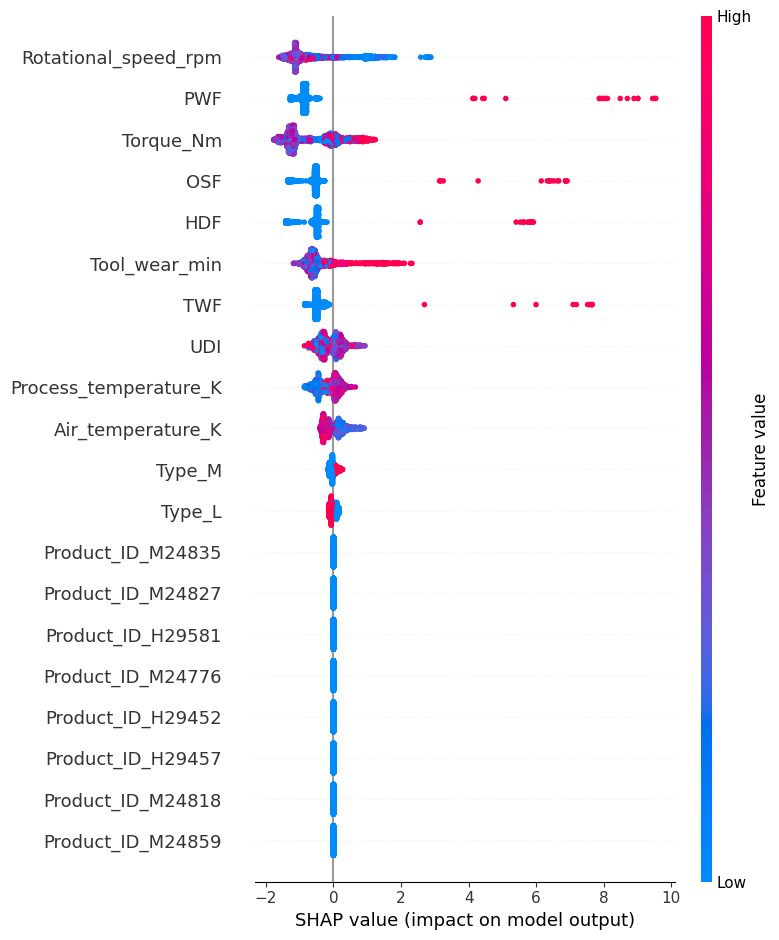

In [20]:
shap.summary_plot(shap_values, X_test)

## LIME Explanation (Single Instance)

In [22]:
lime_explainer = LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=X.columns,
    class_names=["No Failure", "Failure"],
    mode="classification"
)

i = 0  # first test sample
lime_exp = lime_explainer.explain_instance(
    data_row=X_test.iloc[i],
    predict_fn=model.predict_proba
)

#lime_exp.show_in_notebook()
from IPython.display import HTML

HTML(lime_exp.as_html())


c:\Users\Arirot\AppData\Local\Programs\Python\Python314\Lib\site-packages\lime\discretize.py:110: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
c:\Users\Arirot\AppData\Local\Programs\Python\Python314\Lib\site-packages\lime\discretize.py:110: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
c:\Users\Arirot\AppData\Local\Programs\Python\Python314\Lib\site-packages\lime\lime_tabular.py:544: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will alwa

## Save Model for Dashboard

In [23]:
joblib.dump(model, "../models/model.pkl")
print("Model saved to ../models/model.pkl")

Model saved to ../models/model.pkl


# Notebook Ready for Dashboard

Next step: Build the Streamlit dashboard that loads `model.pkl`, SHAP values, and LIME explanations.